<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Bunrong_Bunkhuoch_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cleaning and Feature construction**

In [ ]:
import matplotlib.pyplot as plt
# Initialization
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 23,

    # Thick black axes frame
    "axes.linewidth": 2.3,
    "axes.edgecolor": "black",

    # Tick direction / sides
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    # Tick size
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.minor.size": 7,
    "ytick.minor.size": 7,

    # Tick thickness (this makes them bold)
    "xtick.major.width": 2.3,
    "ytick.major.width": 2.3,
    "xtick.minor.width": 1.8,
    "ytick.minor.width": 1.8,

    # Tick color (black)
    "xtick.color": "black",
    "ytick.color": "black",

    # Tick label size + color
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "xtick.labelcolor": "black",
    "ytick.labelcolor": "black",
})

In [ ]:
import pandas as pd

excel_file_path = '/content/For_ML.xlsx'
df = pd.read_excel(excel_file_path)

In [ ]:
print(df.columns.tolist())

['Weights', 'Staff_Capacity', 'Financial_Readiness', 'Leadership_Support', 'Data_Immutability', 'Access_Control', 'Compatibility', 'Stakeholder_Trust', 'Regulatory_Support', 'Governance_Clarity', 'Readiness Score', 0.11407675666666668, 'Group', 'Experiences', 'Possition', 'Blockchain_Famliliarity']


In [ ]:
df['Blockchain_Famliliarity'] = df['Blockchain_Famliliarity'].replace({'Midium': 'Medium', 'Medium ': 'Medium'})
print("Unique values in 'Blockchain_Famliliarity' column after correction:")
print(df['Blockchain_Famliliarity'].unique())

Unique values in 'Blockchain_Famliliarity' column after correction:
['Medium' 'Low']


In [ ]:
# Columns to attempt to drop
columns_to_drop = ['Weights', 'Possition']

# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Columns {existing_columns_to_drop} dropped successfully.")
else:
    print("No specified columns were found in the DataFrame to drop.")

print("\nDataFrame after attempting to drop columns:")
df = df.rename(columns={0.11407675666666668: 'median'})

display(df.head())

Columns ['Weights', 'Possition'] dropped successfully.

DataFrame after attempting to drop columns:


,Staff_Capacity,Financial_Readiness,Leadership_Support,Data_Immutability,Access_Control,Compatibility,Stakeholder_Trust,Regulatory_Support,Governance_Clarity,Readiness Score,median,Group,Experiences,Blockchain_Famliliarity
0,0.021923,0.239020,0.072390,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0,Private,< 3 years,Medium
1,0.145305,0.528069,0.053310,0.066652,0.066652,0.066652,0.024454,0.024454,0.024454,0.129633,1,Private,< 3 years,Low
2,0.044807,0.488515,0.147953,0.022926,0.022926,0.022926,0.083316,0.083316,0.083316,0.124075,1,Private,< 3 years,Low
3,0.102413,0.558287,0.056361,0.021923,0.021923,0.021923,0.072390,0.072390,0.072390,0.125973,1,Private,< 3 years,Low
4,0.408147,0.185443,0.112311,0.165034,0.017097,0.053143,0.045070,0.010758,0.002997,0.129314,1,Private,< 3 years,Low


In [ ]:
print("Unique values in 'Group' column:")
print(df['Group'].unique())

print("Unique values in 'Experiences' column:")
print(df['Experiences'].unique())

print("Unique values in 'Blockchain_Famliliarity' column:")
print(df['Blockchain_Famliliarity'].unique())

Unique values in 'Group' column:
['Private' 'Public' 'Academia']
Unique values in 'Experiences' column:
['< 3 years' '3–5 years' '> 5 years']
Unique values in 'Blockchain_Famliliarity' column:
['Medium' 'Low']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize separate LabelEncoder instances
group_label_encoder = LabelEncoder()
experiences_label_encoder = LabelEncoder()
BC_label_encoder = LabelEncoder()

# Perform encoding and dropping only if columns exist
if 'Group' in df.columns:
    df['Group_Encoded'] = group_label_encoder.fit_transform(df['Group'])
    print("\nMapping of 'Group' categories to encoded values:")
    for i, item in enumerate(group_label_encoder.classes_):
        print(f"{item}: {i}")


if 'Experiences' in df.columns:
    df['Experiences_Encoded'] = experiences_label_encoder.fit_transform(df['Experiences'])
    print("\nMapping of 'Experiences' categories to encoded values:")
    for i, item in enumerate(experiences_label_encoder.classes_):
        print(f"{item}: {i}")

if 'Blockchain_Famliliarity' in df.columns:
    df['Blockchain_Familiarity'] = BC_label_encoder.fit_transform(df['Blockchain_Famliliarity'])
    print("\nMapping of 'Blockchain_Famliliarity' categories to encoded values:")
    for i, item in enumerate(BC_label_encoder.classes_):
        print(f"{item}: {i}")

# Display the DataFrame with the new encoded column, only including existing columns
print("DataFrame with encoded columns:")
display_cols = []
if 'Group_Encoded' in df.columns:
    display_cols.append('Group_Encoded')
    display_cols.append('Group')
if 'Experiences_Encoded' in df.columns:
    display_cols.append('Experiences_Encoded')
    display_cols.append('Experiences')
if 'Blockchain_Familiarity' in df.columns:
    display_cols.append('Blockchain_Familiarity')
    display_cols.append('Blockchain_Famliliarity')

if display_cols:
    display(df[display_cols].head())
else:
    print("No encoded columns to display.")

df = df.drop(columns="Experiences")
df = df.drop(columns="Group")
df = df.drop(columns="Blockchain_Famliliarity")


Mapping of 'Group' categories to encoded values:
Academia: 0
Private: 1
Public: 2

Mapping of 'Experiences' categories to encoded values:
3–5 years: 0
< 3 years: 1
> 5 years: 2

Mapping of 'Blockchain_Famliliarity' categories to encoded values:
Low: 0
Medium: 1
DataFrame with encoded columns:


,Group_Encoded,Group,Experiences_Encoded,Experiences,Blockchain_Familiarity,Blockchain_Famliliarity
0,1,Private,1,< 3 years,1,Medium
1,1,Private,1,< 3 years,0,Low
2,1,Private,1,< 3 years,0,Low
3,1,Private,1,< 3 years,0,Low
4,1,Private,1,< 3 years,0,Low


In [ ]:
# Create the output DataFrame with 'Blockchain_Famliliarity'
op = "median"
output_df = df[[op]].copy()

# Columns to drop from the input DataFrame
# This includes the 'op' column itself, as it's the target variable,
# and any additional features specified in features_to_drop.
features_to_drop = ['Group_Encoded', "Experiences_Encoded", "Blockchain_Familiarity", "Readiness Score"]
all_columns_to_drop = [op] + features_to_drop

# Filter out columns that do not exist in the DataFrame before dropping
existing_columns_to_drop = [col for col in all_columns_to_drop if col in df.columns]

# Create the input DataFrame by dropping the specified columns from the original df
if existing_columns_to_drop:
    input_df = df.drop(columns=existing_columns_to_drop)
    print(f"Columns {existing_columns_to_drop} dropped successfully from input_df.")
else:
    input_df = df.copy() # If no columns to drop, just copy df
    print("No specified columns were found in the DataFrame to drop for input_df.")


print(f"Output DataFrame ({op}):")
display(output_df.head())

print("\nInput DataFrame (Features):")
display(input_df.head())

Columns ['median', 'Group_Encoded', 'Experiences_Encoded', 'Blockchain_Familiarity', 'Readiness Score'] dropped successfully from input_df.
Output DataFrame (median):


,median
0,0
1,1
2,1
3,1
4,1



Input DataFrame (Features):


,Staff_Capacity,Financial_Readiness,Leadership_Support,Data_Immutability,Access_Control,Compatibility,Stakeholder_Trust,Regulatory_Support,Governance_Clarity
0,0.021923,0.239020,0.072390,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111
1,0.145305,0.528069,0.053310,0.066652,0.066652,0.066652,0.024454,0.024454,0.024454
2,0.044807,0.488515,0.147953,0.022926,0.022926,0.022926,0.083316,0.083316,0.083316
3,0.102413,0.558287,0.056361,0.021923,0.021923,0.021923,0.072390,0.072390,0.072390
4,0.408147,0.185443,0.112311,0.165034,0.017097,0.053143,0.045070,0.010758,0.002997


# **Machine Learning application**

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets (70% train, 30% test) with random sampling
X_train, X_test, y_train, y_test = train_test_split(input_df, output_df, test_size=0.50, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (41, 9)
Shape of X_test: (42, 9)
Shape of y_train: (41, 1)
Shape of y_test: (42, 1)


### Machine Learning Model Evaluation

Given the limited dataset, we will evaluate several classification models to find the best performing one. We will use `Accuracy`, `Precision`, `Recall`, and `F1-Score` as evaluation metrics.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ensure y_train and y_test are 1D arrays for some models
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

# Define a list of classifiers to evaluate
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine (SVC)": SVC(random_state=42, probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

print("\n--- Model Evaluation Results ---")
for name, clf in classifiers.items():
    print(f"\nEvaluating: {name}")

    # Train the model
    clf.fit(X_train, y_train_1d)

    # Make predictions
    y_pred = clf.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test_1d, y_pred)
    precision = precision_score(y_test_1d, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_1d, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_1d, y_pred, average='weighted', zero_division=0)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")


--- Model Evaluation Results ---

Evaluating: Logistic Regression
  Accuracy: 0.9524
  Precision: 0.9567
  Recall: 0.9524
  F1-Score: 0.9524

Evaluating: Decision Tree
  Accuracy: 0.6905
  Precision: 0.7095
  Recall: 0.6905
  F1-Score: 0.6789

Evaluating: Random Forest
  Accuracy: 0.9048
  Precision: 0.9048
  Recall: 0.9048
  F1-Score: 0.9048

Evaluating: Support Vector Machine (SVC)
  Accuracy: 0.8333
  Precision: 0.8519
  Recall: 0.8333
  F1-Score: 0.8299

Evaluating: K-Nearest Neighbors
  Accuracy: 0.7619
  Precision: 0.8032
  Recall: 0.7619
  F1-Score: 0.7505

Evaluating: Gaussian Naive Bayes
  Accuracy: 0.8810
  Precision: 0.8882
  Recall: 0.8810
  F1-Score: 0.8799

Evaluating: Gradient Boosting
  Accuracy: 0.7381
  Precision: 0.7642
  Recall: 0.7381
  F1-Score: 0.7283


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ensure y_train and y_test are 1D arrays for model training
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

# Define the model (user can change this to any other classifier)
model = LogisticRegression(random_state=42, solver='liblinear')
# model = RandomForestClassifier(random_state=42)
# model = GradientBoostingClassifier(random_state=42)
# model = SVC(random_state=42, probability=True)

model_name = "Logistic Regression"
# model_name = "Random Forest Classifier"
# model_name = "Gradient Boosting Classifier"
# model_name = "Support Vector Mechanics"

print(f"\n--- Training and Validating: {model_name} ---")

# Train the model
model.fit(X_train, y_train_1d)

# Make predictions
y_pred_single = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test_1d, y_pred_single)
precision = precision_score(y_test_1d, y_pred_single, average='weighted', zero_division=0)
recall = recall_score(y_test_1d, y_pred_single, average='weighted', zero_division=0)
f1 = f1_score(y_test_1d, y_pred_single, average='weighted', zero_division=0)

print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")



--- Training and Validating: Logistic Regression ---
  Accuracy: 0.9524
  Precision: 0.9567
  Recall: 0.9524
  F1-Score: 0.9524


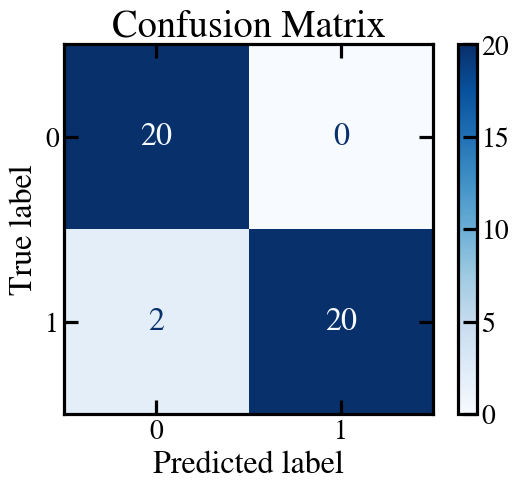

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test_1d, y_pred_single)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
# plt.show()
plt.savefig('Confusion Matrix.png', dpi=300)

Using KernelExplainer for the current model: LogisticRegression


  0%|          | 0/42 [00:00<?, ?it/s]


--- SHAP Summary Plot ---


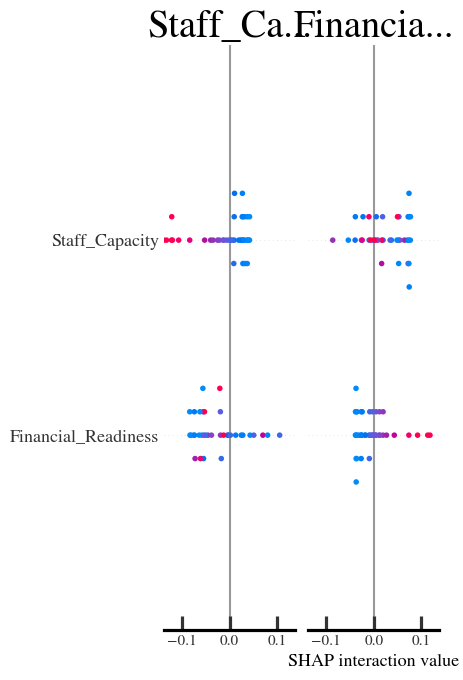

In [ ]:
import shap
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Initialize JS for SHAP plots
shap.initjs()

# --- Conditional SHAP Explainer Creation ---
# This section automatically selects the appropriate SHAP explainer
# based on the type of your currently selected 'model'.
# You can switch your model in the cell above (RYt8N7SCN7_3) and re-run.

explainer = None
shap_values = None

if isinstance(model, (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier)):
    # Use TreeExplainer for tree-based models, as it's optimized for them.
    print(f"Using TreeExplainer for the current model: {type(model).__name__}")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
elif isinstance(model, (SVC, LogisticRegression, KNeighborsClassifier, GaussianNB)):
    # Use KernelExplainer for non-tree-based models. It's more general but can be slower.
    # It requires a background dataset (e.g., X_train) and a prediction function (model.predict_proba for classification).
    print(f"Using KernelExplainer for the current model: {type(model).__name__}")
    # Using X_train as the background dataset. For very large datasets, consider sampling X_train.
    explainer = shap.KernelExplainer(model.predict_proba, X_train)
    # KernelExplainer for classification typically returns shap_values as a list of arrays (one for each class).
    shap_values = explainer.shap_values(X_test)
else:
    print(f"Unsupported model type for SHAP explanation: {type(model).__name__}. Please add support for this model type.")


if explainer is not None and shap_values is not None:
    # Plot the SHAP summary plot
    print("\n--- SHAP Summary Plot ---")
    # For binary classification, if shap_values is a list, we usually plot the SHAP values
    # for the positive class (index 1) to understand feature impact on predicting '1'.
    if isinstance(shap_values, list) and len(shap_values) > 1:
        shap.summary_plot(shap_values[1], X_test, feature_names=X_test.columns)
    else:
        # For single-output models or if TreeExplainer returns a single array for binary.
        shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

    # Optional: Plot the SHAP dependence plot for the most important feature
    # To use this, uncomment the lines below.
    # print(f"\n--- SHAP Dependence Plot for the most important feature ---")
    # if isinstance(shap_values, list) and len(shap_values) > 1:
    #     abs_shap_vals = np.abs(shap_values[1]).mean(0)
    # else:
    #     abs_shap_vals = np.abs(shap_values).mean(0)
    # most_important_feature_index = np.argmax(abs_shap_vals)
    # most_important_feature_name = X_test.columns[most_important_feature_index]
    # shap.dependence_plot(most_important_feature_name, shap_values, X_test, interaction_index=None)


   EXACT VALUES FOR TABLE 16
             Factor  SHAP_value  SHAP_rank
     Staff_Capacity       0.040          1
Financial_Readiness       0.028          2
  Stakeholder_Trust       0.027          3
  Data_Immutability       0.024          4
 Regulatory_Support       0.012          5
     Access_Control       0.011          6
 Leadership_Support       0.010          7
 Governance_Clarity       0.009          8
      Compatibility       0.001          9


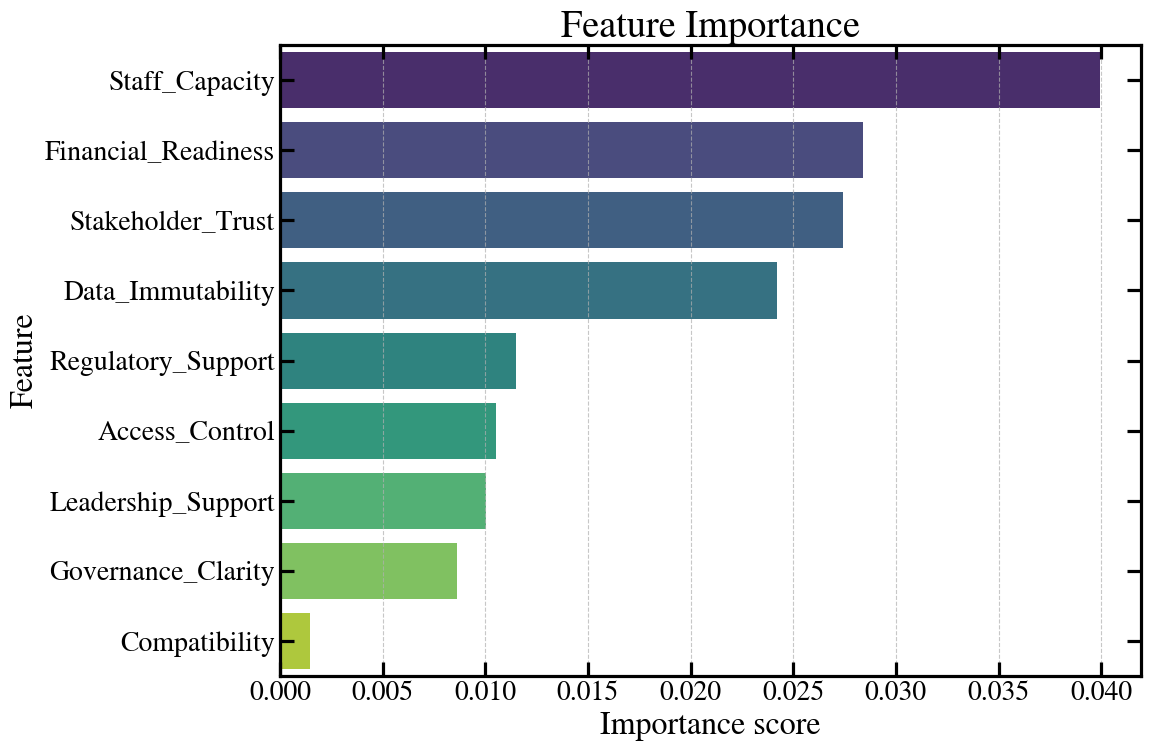

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Determine the SHAP values for plotting (for the positive class in binary classification)
# This logic aims to produce a 2D array of (num_samples, num_features)
# regardless of whether shap_values is a list of arrays or a 3D array.
shap_values_for_plotting = None

if isinstance(shap_values, list):
    # This is the standard output for TreeExplainer/KernelExplainer in binary classification.
    # shap_values is a list of two 2D arrays: [shap_values_class_0, shap_values_class_1]
    if len(shap_values) > 1:
        shap_values_for_plotting = shap_values[1]  # Get SHAP values for the positive class (class 1)
    else:
        # Fallback for single-output list (e.g., regression or if only one class output)
        shap_values_for_plotting = shap_values[0]
elif isinstance(shap_values, np.ndarray):
    # This case appears to be what's happening based on the kernel state
    # where shap_values is a 3D array (num_samples, num_features, num_classes)
    if shap_values.ndim == 3:
        # Select the SHAP values for the positive class (class 1)
        shap_values_for_plotting = shap_values[:, :, 1]
    elif shap_values.ndim == 2:
        # If it's already a 2D array (samples, features), use it directly
        shap_values_for_plotting = shap_values
    else:
        print(f"Warning: Unexpected ndim for shap_values: {shap_values.ndim}. Cannot determine plotting values.")
else:
    print(f"Warning: Unexpected type for shap_values: {type(shap_values)}. Cannot determine plotting values.")

# Calculate the mean absolute SHAP value for each feature from the selected plotting values
mean_abs_shap = None
if shap_values_for_plotting is not None and shap_values_for_plotting.ndim == 2:
    mean_abs_shap = np.mean(np.abs(shap_values_for_plotting), axis=0)
elif shap_values_for_plotting is not None and shap_values_for_plotting.ndim == 1: # Fallback for single feature case
    mean_abs_shap = np.abs(shap_values_for_plotting)
else:
    print("Could not obtain a 2D or 1D array for shap_values_for_plotting to calculate mean_abs_shap.")
# ── ADD THIS CELL between your SHAP compute cell and your plotting cell ──────

# Extract mean absolute SHAP values (mirrors the same logic as your plot cell)
if isinstance(shap_values, list):
    sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

mean_abs = np.mean(np.abs(sv), axis=0)

table16 = pd.DataFrame({
    'Factor':      X_test.columns,
    'SHAP_value':  mean_abs.round(3),
    'SHAP_rank':   pd.Series(mean_abs).rank(ascending=False).astype(int)
}).sort_values('SHAP_value', ascending=False).reset_index(drop=True)

print("=" * 40)
print("   EXACT VALUES FOR TABLE 16")
print("=" * 40)
print(table16.to_string(index=False))
print("=" * 40)

if mean_abs_shap is not None and len(mean_abs_shap) == len(X_test.columns):
    feature_importance = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': mean_abs_shap
    })

    # Sort the features by importance
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    # Create the bar plot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis', hue='Feature', legend=False)
    plt.title('Feature Importance')
    plt.xlabel('Importance score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # plt.show()
    plt.savefig('feature_importance.png', dpi=300)
else:
    print("Could not calculate or plot feature importance. Check shap_values structure or X_test.columns length.")

# **Reconstruction_by_ML**

In [ ]:
import pandas as pd
import numpy as np

# 1. Combine input_df and output_df to get the full dataset with encoded values and original indices
#    input_df contains features, output_df contains 'op' (e.g., 'median')
full_data_encoded = pd.concat([input_df, output_df], axis=1)

# Rename the actual target column for clarity
full_data_encoded = full_data_encoded.rename(columns={op: f'Actual_{op}'})

# 2. Initialize 'Predicted_{op}' column with NaN for all rows
full_data_encoded[f'Predicted_{op}'] = np.nan

# 3. Populate 'Predicted_{op}' for the test set rows only
#    X_test retains original indices, y_pred_single are the predictions for X_test
predictions_series = pd.Series(y_pred_single, index=X_test.index)
full_data_encoded.loc[X_test.index, f'Predicted_{op}'] = predictions_series

# Create a working copy for further reconstruction
reconstructed_df_full = full_data_encoded.copy()

# New Step: Add back specific features from the original 'df' that were dropped from 'input_df'
user_requested_cols_to_add_back = ['Group_Encoded', 'Experiences_Encoded', 'Blockchain_Familiarity', 'Readiness Score']

# Filter for columns that exist in the original `df` and are not already in `reconstructed_df_full`
cols_to_add_from_original_df = [
    col for col in user_requested_cols_to_add_back
    if col in df.columns and col not in reconstructed_df_full.columns
]

if cols_to_add_from_original_df:
    # Select these columns from the original `df` using the index of `reconstructed_df_full`
    columns_from_original_df_for_merge = df.loc[reconstructed_df_full.index, cols_to_add_from_original_df]
    reconstructed_df_full = pd.concat([reconstructed_df_full, columns_from_original_df_for_merge], axis=1)
    print(f"Added back user-requested columns from original df: {cols_to_add_from_original_df}")
else:
    print("No additional user-requested columns from features_to_drop were found or needed to be added back.")


# 4. Remap encoded columns back to original categories (Group, Experiences)
#    Now that 'Group_Encoded' and 'Experiences_Encoded' might be added back,
#    we can inverse transform them to get the original categorical values.
#    The user specifically asked to *add back* the encoded columns, so we will not drop them after remapping.

# Remap 'Group_Encoded'
if 'Group_Encoded' in reconstructed_df_full.columns and 'group_label_encoder' in locals():
    # Ensure the column is integer type before inverse_transform
    reconstructed_df_full['Group'] = group_label_encoder.inverse_transform(reconstructed_df_full['Group_Encoded'].astype(int))
    # Do NOT drop Group_Encoded here, as the user asked to add it back.
    # reconstructed_df_full = reconstructed_df_full.drop(columns=['Group_Encoded'])

# Remap 'Experiences_Encoded'
if 'Experiences_Encoded' in reconstructed_df_full.columns and 'experiences_label_encoder' in locals():
    # Ensure the column is integer type before inverse_transform
    reconstructed_df_full['Experiences'] = experiences_label_encoder.inverse_transform(reconstructed_df_full['Experiences_Encoded'].astype(int))
    # Do NOT drop Experiences_Encoded here, as the user asked to add it back.
    # reconstructed_df_full = reconstructed_df_full.drop(columns=['Experiences_Encoded'])

# 5. Add back 'Weights' and 'Possition' columns from the original_df_full (if available)
#    'original_df_full' is available from previous cells. We ensure it's used with aligned indices.
if 'Weights' not in reconstructed_df_full.columns and 'Possition' not in reconstructed_df_full.columns:
    # The previous cell showed a warning: "Warning: 'original_df_full' not found"
    # This block won't run, but keeping it for robustness if original_df_full is loaded later.
    if 'original_df_full' in locals() and 'Weights' in original_df_full.columns and 'Possition' in original_df_full.columns:
        original_cols_to_add = original_df_full.loc[reconstructed_df_full.index, ['Weights', 'Possition']]
        reconstructed_df_full = pd.concat([original_cols_to_add, reconstructed_df_full], axis=1)
    else:
        print("Warning: 'original_df_full' not found or 'Weights'/'Possition' not in it. Unable to re-add these columns.")

# 6. Reorder columns to place 'Actual_{op}' and 'Predicted_{op}' at the end
cols = reconstructed_df_full.columns.tolist()

# Define the new target output columns based on the current 'op'
target_output_cols = [f'Actual_{op}', f'Predicted_{op}']

# Remove them from their current position in the list, if they exist
for col in target_output_cols:
    if col in cols:
        cols.remove(col)

# Append them to the end of the column list
cols.extend(target_output_cols)

# Apply the new column order to the DataFrame
reconstructed_df_full = reconstructed_df_full[cols]
reconstructed_df_full= reconstructed_df_full.drop(columns="Group_Encoded")
reconstructed_df_full= reconstructed_df_full.drop(columns="Experiences_Encoded")

print("Reconstructed DataFrame for visual inspection (Full Data with predictions for test set):")
display(reconstructed_df_full.head())
display(reconstructed_df_full.tail()) # Display tail to show predicted values for test set

Added back user-requested columns from original df: ['Group_Encoded', 'Experiences_Encoded', 'Blockchain_Familiarity', 'Readiness Score']
Reconstructed DataFrame for visual inspection (Full Data with predictions for test set):


,Staff_Capacity,Financial_Readiness,Leadership_Support,Data_Immutability,Access_Control,Compatibility,Stakeholder_Trust,Regulatory_Support,Governance_Clarity,Blockchain_Familiarity,Readiness Score,Group,Experiences,Actual_median,Predicted_median
0,0.021923,0.239020,0.072390,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,1,0.111111,Private,< 3 years,0,0.0
1,0.145305,0.528069,0.053310,0.066652,0.066652,0.066652,0.024454,0.024454,0.024454,0,0.129633,Private,< 3 years,1,NaN
2,0.044807,0.488515,0.147953,0.022926,0.022926,0.022926,0.083316,0.083316,0.083316,0,0.124075,Private,< 3 years,1,NaN
3,0.102413,0.558287,0.056361,0.021923,0.021923,0.021923,0.072390,0.072390,0.072390,0,0.125973,Private,< 3 years,1,1.0
4,0.408147,0.185443,0.112311,0.165034,0.017097,0.053143,0.045070,0.010758,0.002997,0,0.129314,Private,< 3 years,1,1.0


,Staff_Capacity,Financial_Readiness,Leadership_Support,Data_Immutability,Access_Control,Compatibility,Stakeholder_Trust,Regulatory_Support,Governance_Clarity,Blockchain_Familiarity,Readiness Score,Group,Experiences,Actual_median,Predicted_median
78,0.104619,0.101005,0.083879,0.208783,0.079668,0.091196,0.105302,0.104421,0.121126,1,0.109781,Academia,3–5 years,0,NaN
79,0.156863,0.156863,0.156863,0.019608,0.019608,0.019608,0.156863,0.156863,0.156863,1,0.112255,Academia,< 3 years,0,NaN
80,0.141570,0.013267,0.033570,0.168608,0.056203,0.505824,0.007360,0.036799,0.036799,1,0.112411,Academia,< 3 years,0,NaN
81,0.200000,0.200000,0.200000,0.062163,0.098681,0.039156,0.066667,0.066667,0.066667,1,0.122667,Public,< 3 years,1,NaN
82,0.135118,0.085118,0.107241,0.189782,0.091240,0.131581,0.054544,0.142941,0.062436,1,0.112639,Academia,< 3 years,0,0.0


In [ ]:
output_excel_path = 'ML_predicted.xlsx'
reconstructed_df_full.to_excel(output_excel_path, index=False)
print(f"Reconstructed DataFrame saved to '{output_excel_path}'")

Reconstructed DataFrame saved to 'ML_predicted.xlsx'
